# **Match Song Lyrics to Artists**

In this assignment, you are asked to match song lyrics to their respective artists. Steps to the assignment:
1. Download the song lyrics. You can download the data from this link: https://www.kaggle.com/datasets/deepshah16/song-lyrics-dataset/data
1. Preprocess your dataset to your liking. You are free to use any preprocessing with any libraries. Make sure to apply the preprocessing to the whole dataset, even the test part.
1. Split your dataset into train/dev/test sets with 0.70/0.15/0.15 proportions. Select a random state number and use it consistently to get the same sets while iterating. **This is very important!**
1. Select your features for the task: word n-grams (unigram, bigram, trigram), character n-grams, TF-IDF, and so on.
1. Use three different approaches to solve the task: Some examples are Naive Bayes, Logistic Regression, SVM, KNNs, and neural networks classification methods with the dataset. **You need to select Naive Bayes as one of the methods and code Naive Bayes with the MLE approach from scratch.**
1. Compare different classification methods and show confusion matrices for each method.
1. Write a small report on your approaches and results.


## Rules
### Allowed:
 - Use any libraries for preprocessing, feature selection, vector making, training, and predicting for the task, **other than the Naive Bayes classifier**.
 - Adding additional coding blocks
 - Use spaCy for Named Entity Recognition and Part-of-Speech tagging (next week's content but will be helpful for this assignment)

### Not allowed:
 - Using metadata in the dataset given. You must use **only** the lyrics of the song. For example, do not use the release year to assign authorship.
 - **You need to write your own Naive Bayes classifier.** Using the Naive Bayes classifier from an external library is not allowed.
 - Running your code with the test split of your data. You can run this just before you submit your system. We will run your system on your test data in the evaluation.
 - Changing the contents of the evaluation block at the end of the notebook.

## Assignment Report
Please write a short assignment report at the end of the notebook (max 500 words). Please include all of the following points in the report:
 - Preprocessing method
 - Selection of the features and the reasoning for the selections
 - Selection of the classification methods and the reasoning for the selection
 - Challenges you have faced while writing the tokenizer and challenges with the specific corpus
 - Limitations of your approach
 - Possible improvements to the system

## Grading
You will be graded with the following criteria:
 - running complete code (0.5),
 - clear commenting (0.5),
 - data loading and concatenation (0.5),
 - exploratory data analysis (EDA) - Artist Histogram Plot (0.5)
 - preprocessing function (0.5)
 - naive bayes implementation (1)
 - feature engineering (1)
 - model training and evaluation for at least 3 classification methods (including naive bayes) (1.5)
 - confusion matrix for each method (0.5)
 - assignment report (1).

Total points for this assignment = 7.5

You can get bonus points (maximum 0.5) by trying neural networks as one of the classifiers.

## Submission

Submission will be made to SUCourse. Please submit your file using the following naming convention.


`studentid_studentname_tokenizer.ipynb  - ex. 26744_aysegulrana_tokenizer.ipynb`


**Deadline is November 14nd, 23.55pm.**

### 1. Data Loading and Concatenation  (hint: use zipfile library for loading the zip file and concatenate the csv files)

Use pandas library to read your dataset into df object below.

In [2]:
import zipfile
import pandas as pd

def load_and_concatenate_zip(zip_path):
    # Open the zip file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # List all file names inside the zip
        file_list = zip_ref.namelist()

        # Select only the .csv files in the "csv/" folder
        csv_files = [f for f in file_list if f.startswith("csv/") and f.endswith(".csv")]

        # If no CSV files are found, print a warning
        if not csv_files:
            print("CSV files not found in the zip.")
            return pd.DataFrame()

        # Create an empty list to store each DataFrame
        dataframes = []

        # Loop through each CSV file
        for file in csv_files:
            with zip_ref.open(file) as f:

                df = pd.read_csv(f)

                # Extract the artist name from the file name and add it as a new column
                artist_name = file.split("/")[-1].replace(".csv", "")
                df['artist'] = artist_name

                # Append the DataFrame to the list
                dataframes.append(df)

        # Concatenate all DataFrames into one
        concatenated_df = pd.concat(dataframes, ignore_index=True)

        # Drop the unnecessary "Unnamed: 0" column
        concatenated_df = concatenated_df.drop(columns=["Unnamed: 0"], errors="ignore")

        return concatenated_df

# Define the path to the zip file and load the concatenated data
zip_path = "archive.zip"
df = load_and_concatenate_zip(zip_path)

print(df.head())
print(df.columns)
print(df.sample(5))
# Display unique artist names
print(df['artist'].unique())
# Display the total number of rows
print("Total number of rows:", len(df))


          Artist                   Title            Album        Date  \
0  Ariana Grande          ​thank u, next    thank u, next  2018-11-03   
1  Ariana Grande                 7 rings    thank u, next  2019-01-18   
2  Ariana Grande         ​God is a woman        Sweetener  2018-07-13   
3  Ariana Grande            Side To Side  Dangerous Woman  2016-05-20   
4  Ariana Grande  ​​no tears left to cry        Sweetener  2018-04-20   

                                               Lyric    Year        artist  
0  thought i'd end up with sean but he wasn't a m...  2018.0  ArianaGrande  
1  yeah breakfast at tiffany's and bottles of bub...  2019.0  ArianaGrande  
2  you you love it how i move you you love it how...  2018.0  ArianaGrande  
3  ariana grande  nicki minaj i've been here all ...  2016.0  ArianaGrande  
4  right now i'm in a state of mind i wanna be in...  2018.0  ArianaGrande  
Index(['Artist', 'Title', 'Album', 'Date', 'Lyric', 'Year', 'artist'], dtype='object')
            

### 2. Data Cleaning (Look at value count of each lyric and remove unnecessary or empty lyrics after this process view length of the dataframe to see the change)

In [3]:
# Import necessary libraries
import pandas as pd

def clean_lyrics_data(df, min_lyrics_length=20, max_repeats=3):
    """
    Clean lyrics data by removing rows with NaN or empty lyrics, short lyrics, and overly repeated lyrics.

    Parameters:
    - df (DataFrame): The DataFrame containing the lyrics data.
    - min_lyrics_length (int): Minimum length of lyrics to keep.
    - max_repeats (int): Maximum allowed occurrences of the same lyrics.

    Returns:
    - DataFrame: Cleaned DataFrame
    """
    # Make a copy of the original data to avoid altering it
    df_cleaned = df.copy()

    # Initial DataFrame length
    initial_length = len(df_cleaned)
    print("Initial Number of Rows:", initial_length)

    # 1. Remove rows with NaN or empty lyrics
    df_cleaned = df_cleaned.dropna(subset=['Lyric'])
    df_cleaned = df_cleaned[df_cleaned['Lyric'].str.strip() != '']

    # 2. Remove lyrics that are too short (e.g., less than specified characters)
    df_cleaned = df_cleaned[df_cleaned['Lyric'].str.len() > min_lyrics_length]

    # 3. Remove overly repeated lyrics based on max_repeats
    lyrics_counts = df_cleaned['Lyric'].value_counts()
    common_lyrics_to_remove = lyrics_counts[lyrics_counts >= max_repeats].index
    df_cleaned = df_cleaned[~df_cleaned['Lyric'].isin(common_lyrics_to_remove)]

    # Check final DataFrame length and statistics after cleaning
    final_length = len(df_cleaned)
    print("\nNumber of Rows After Cleaning:", final_length)
    print("Number of Rows Removed:", initial_length - final_length)

    # Display a few rows of the cleaned DataFrame
    print("\nFirst Rows of Cleaned Data:")
    print(df_cleaned.head())

    # Return cleaned DataFrame
    return df_cleaned

# Apply cleaning function to the DataFrame
df_cleaned = clean_lyrics_data(df)

# Display unique artists and statistics about the cleaned data for insight
print("Unique artists in cleaned data:", df_cleaned['artist'].nunique())
print("Average lyrics length after cleaning:", df_cleaned['Lyric'].str.len().mean())
print("Median lyrics length after cleaning:", df_cleaned['Lyric'].str.len().median())


Initial Number of Rows: 6027

Number of Rows After Cleaning: 5645
Number of Rows Removed: 382

First Rows of Cleaned Data:
          Artist                   Title            Album        Date  \
0  Ariana Grande          ​thank u, next    thank u, next  2018-11-03   
1  Ariana Grande                 7 rings    thank u, next  2019-01-18   
2  Ariana Grande         ​God is a woman        Sweetener  2018-07-13   
3  Ariana Grande            Side To Side  Dangerous Woman  2016-05-20   
4  Ariana Grande  ​​no tears left to cry        Sweetener  2018-04-20   

                                               Lyric    Year        artist  
0  thought i'd end up with sean but he wasn't a m...  2018.0  ArianaGrande  
1  yeah breakfast at tiffany's and bottles of bub...  2019.0  ArianaGrande  
2  you you love it how i move you you love it how...  2018.0  ArianaGrande  
3  ariana grande  nicki minaj i've been here all ...  2016.0  ArianaGrande  
4  right now i'm in a state of mind i wanna be in... 

### 3. Exploratory Data Analysis (EDA) - Artist Histogram (Create a histogram for the number of lyrics of each artist using matplotlib)

<ipython-input-4-7b5ae6f9279f>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=artist_counts.index, y=artist_counts.values, palette='viridis')


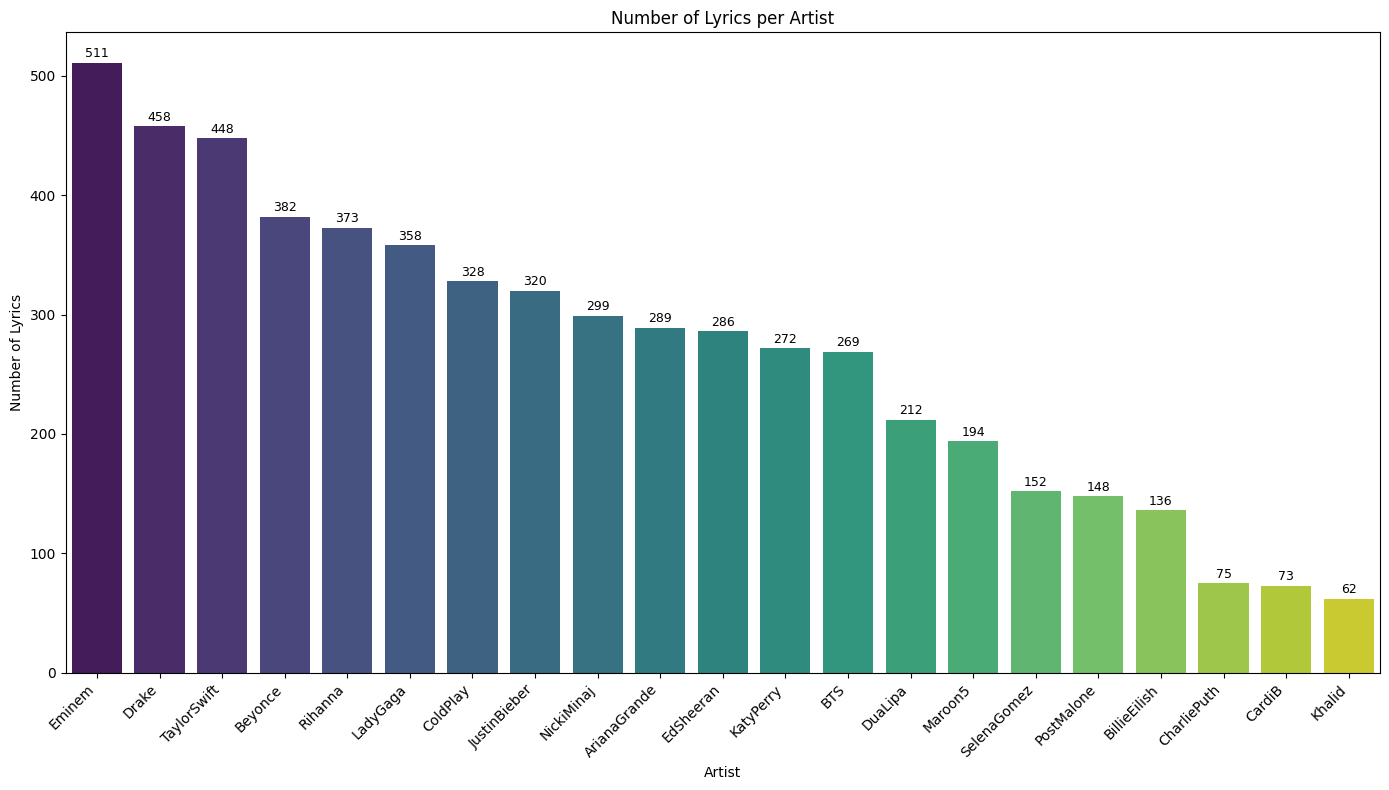

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of lyrics per artist
artist_counts = df_cleaned['artist'].value_counts()

# Create a barplot for all artists
plt.figure(figsize=(14, 8))
sns.barplot(x=artist_counts.index, y=artist_counts.values, palette='viridis')

# Rotate artist names for better readability
plt.xticks(rotation=45, ha='right')
plt.xlabel("Artist")
plt.ylabel("Number of Lyrics")
plt.title("Number of Lyrics per Artist")
plt.tight_layout()

# Add data labels on top of each bar
for i, count in enumerate(artist_counts.values):
    plt.text(i, count + 2, str(count), ha='center', va='bottom', fontsize=9)

plt.show()


### 4. Preprocessing Function (Create a preprocess function for the lyrics)

In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Download required NLTK data (only needed for the first run)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")

def preprocess_data(df, use_lemmatization=False):
    """
    Preprocess function for cleaning and preparing song lyrics.

    Parameters:
    - df (DataFrame): DataFrame containing the lyrics data
    - use_lemmatization (bool): Whether to use lemmatization instead of stemming

    Returns:
    - DataFrame: DataFrame with a new column 'Processed_Lyric' containing cleaned lyrics
    """
    # Make a copy of the original data to avoid altering it
    df = df.dropna(subset=['Lyric']).copy()

    # 1. Convert to lowercase
    df['Lyric'] = df['Lyric'].apply(lambda x: str(x).lower() if isinstance(x, str) else x)

    # 2. Remove unwanted characters (punctuation, numbers, etc.)
    df['Lyric'] = df['Lyric'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x) if isinstance(x, str) else x)

    # 3. Remove stopwords
    df['Lyric'] = df['Lyric'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]) if isinstance(x, str) else x)

    # 4. Stemming or Lemmatization
    if use_lemmatization:
        from nltk.stem import WordNetLemmatizer
        nltk.download('wordnet')
        nltk.download('omw-1.4')
        lemmatizer = WordNetLemmatizer()
        df['Lyric'] = df['Lyric'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]) if isinstance(x, str) else x)
    else:
        df['Lyric'] = df['Lyric'].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]) if isinstance(x, str) else x)

    # Add cleaned lyrics as a new column
    df['Processed_Lyric'] = df['Lyric']

    return df

# Apply the preprocessing function to the dataset
df_cleaned = preprocess_data(df)

# Check the cleaned data
print(df_cleaned[['Lyric', 'Processed_Lyric']].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                               Lyric  \
0  thought id end sean wasnt match wrote song ric...   
1  yeah breakfast tiffani bottl bubbl girl tattoo...   
2  love move love touch one said done youll belie...   
3  ariana grand nicki minaj ive night ariana ive ...   
4  right im state mind wanna like time aint got t...   

                                     Processed_Lyric  
0  thought id end sean wasnt match wrote song ric...  
1  yeah breakfast tiffani bottl bubbl girl tattoo...  
2  love move love touch one said done youll belie...  
3  ariana grand nicki minaj ive night ariana ive ...  
4  right im state mind wanna like time aint got t...  


#### Train Dev Test split
Separate the song lyrics (documents) with respective artist names (labels). Split the dataset into train/dev/test datasets with 0.70/0.15/0.15 proportions.

In [6]:
from sklearn.model_selection import train_test_split

# Separate features (lyrics) and labels (artist names)
X = df_cleaned['Processed_Lyric']  # Column containing processed lyrics
y = df_cleaned['artist']  # Column containing artist names as labels

# 1. Split the data into 70% training and 30% temporary (for dev and test splits)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# 2. Split the temporary data into 15% dev and 15% test, which makes up 50% of the temporary data
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Check the sizes of each dataset
print("Training Set Size:", len(X_train))
print("Validation (Dev) Set Size:", len(X_dev))
print("Test Set Size:", len(X_test))


Training Set Size: 4186
Validation (Dev) Set Size: 897
Test Set Size: 898


### 5. Implement a Naive Bayes classifier with Bag-of-Words features **from** scratch. You are not allowed to use external libraries for training a NB classifier.

In [7]:
import numpy as np
from collections import defaultdict, Counter

class NaiveBayesClassifier:
    def __init__(self, alpha=1.0, min_word_freq=2):
        """
        Initialize Naive Bayes classifier with Laplace smoothing.
        alpha: Smoothing parameter to handle unseen words.
        min_word_freq: Minimum frequency for words to be included in the vocabulary.
        """
        self.alpha = alpha
        self.min_word_freq = min_word_freq
        self.word_counts = defaultdict(Counter)  # Stores word frequencies per artist
        self.artist_counts = Counter()  # Stores song count per artist
        self.vocab = set()  # Stores vocabulary

    def train(self, X, y):
        """
        Train the Naive Bayes classifier on the provided data.
        X: List of lyrics
        y: Corresponding artist labels
        """
        # Count words for each artist and build vocabulary
        for lyric, artist in zip(X, y):
            self.artist_counts[artist] += 1
            for word in lyric.split():
                self.word_counts[artist][word] += 1
                self.vocab.add(word)

        # Filter vocabulary based on minimum word frequency
        self.vocab = {word for word in self.vocab if sum(self.word_counts[artist][word] for artist in self.artist_counts) >= self.min_word_freq}

        # Calculate total word counts per artist
        self.total_words = {artist: sum(self.word_counts[artist][word] for word in self.vocab) for artist in self.artist_counts}
        self.total_docs = len(y)

    def predict(self, lyric):
        """
        Predict the artist for a given lyric.
        lyric: Input lyric (string)
        """
        artist_probs = {}

        # Calculate log-probability for each artist
        for artist in self.artist_counts:
            # Initial probability (prior)
            log_prob = np.log(self.artist_counts[artist] / self.total_docs)

            # Word probability in lyric
            for word in lyric.split():
                if word in self.vocab:
                    word_freq = self.word_counts[artist][word]
                    word_prob = (word_freq + self.alpha) / (self.total_words[artist] + self.alpha * len(self.vocab))
                    log_prob += np.log(word_prob)

            artist_probs[artist] = log_prob

        # Return artist with highest probability
        return max(artist_probs, key=artist_probs.get)

    def evaluate(self, X_test, y_test):
        """
        Calculate accuracy on the test set.
        X_test: Test lyrics
        y_test: True artist labels
        """
        correct = 0
        for lyric, true_artist in zip(X_test, y_test):
            predicted_artist = self.predict(lyric)
            if predicted_artist == true_artist:
                correct += 1
        return correct / len(y_test)


### 6. Feature Selection and Engineering for other two classification methods - Select your features and convert your data with respect to these features. For example, if you will use numerical representation, use appropriate methods to transform your data to vectors.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.sparse import hstack

def vectorize_text_features(X_train, X_dev, X_test, max_features_bow=5000, max_features_tfidf=5000, max_features_char=3000, ngram_range_char=(3, 5)):
    """
    Vectorize text data using Bag-of-Words, TF-IDF, and character n-gram TF-IDF.

    Parameters:
    - X_train, X_dev, X_test: Input text data (training, development, test sets)
    - max_features_bow: Maximum number of features for Bag-of-Words
    - max_features_tfidf: Maximum number of features for TF-IDF
    - max_features_char: Maximum number of features for character n-gram TF-IDF
    - ngram_range_char: Range of n-grams for character-level TF-IDF

    Returns:
    - Combined sparse matrices for training, dev, and test sets
    """

    # Bag-of-Words Vectorizer
    bow_vectorizer = CountVectorizer(max_features=max_features_bow)
    X_bow_train = bow_vectorizer.fit_transform(X_train)
    X_bow_dev = bow_vectorizer.transform(X_dev)
    X_bow_test = bow_vectorizer.transform(X_test)

    # TF-IDF Vectorizer
    tfidf_vectorizer = TfidfVectorizer(max_features=max_features_tfidf)
    X_tfidf_train = tfidf_vectorizer.fit_transform(X_train)
    X_tfidf_dev = tfidf_vectorizer.transform(X_dev)
    X_tfidf_test = tfidf_vectorizer.transform(X_test)

    # Character N-grams TF-IDF Vectorizer
    char_tfidf_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=ngram_range_char, max_features=max_features_char)
    X_char_tfidf_train = char_tfidf_vectorizer.fit_transform(X_train)
    X_char_tfidf_dev = char_tfidf_vectorizer.transform(X_dev)
    X_char_tfidf_test = char_tfidf_vectorizer.transform(X_test)

    # Combine all features into a single sparse matrix
    X_combined_train = hstack([X_bow_train, X_tfidf_train, X_char_tfidf_train])
    X_combined_dev = hstack([X_bow_dev, X_tfidf_dev, X_char_tfidf_dev])
    X_combined_test = hstack([X_bow_test, X_tfidf_test, X_char_tfidf_test])

    return X_combined_train, X_combined_dev, X_combined_test

# Apply vectorization to training, dev, and test sets
X_combined_train, X_combined_dev, X_combined_test = vectorize_text_features(X_train, X_dev, X_test)

# Output the shape of the combined feature sets
print("Combined feature shape (train):", X_combined_train.shape)
print("Combined feature shape (dev):", X_combined_dev.shape)
print("Combined feature shape (test):", X_combined_test.shape)


Combined feature shape (train): (4186, 13000)
Combined feature shape (dev): (897, 13000)
Combined feature shape (test): (898, 13000)


### 7. Model Training and Evaluation
#### - Use several models to train on the dataset
#### - Use development dataset to see your system performances and optimize your system as you want.
#### - Lastly, evaluate your results with accuracy and F1 scores using test set.
#### - Report on the performance on the test set with comparison between methods and confusion matrices.

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.1456 - loss: 2.9893 - val_accuracy: 0.4693 - val_loss: 2.1486
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.4246 - loss: 2.0549 - val_accuracy: 0.5741 - val_loss: 1.6323
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.5824 - loss: 1.5066 - val_accuracy: 0.6265 - val_loss: 1.4187
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.6726 - loss: 1.1664 - val_accuracy: 0.6600 - val_loss: 1.2827
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.7471 - loss: 0.9040 - val_accuracy: 0.6722 - val_loss: 1.2507
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.8059 - loss: 0.7059 - val_accuracy: 0.6734 - val_loss: 1.2587
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.8200 - loss: 0.6354 - val_accuracy: 0.6756 - val_loss: 1.2719
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8573 - loss: 0.5064 - val_accuracy: 0.6667 - v

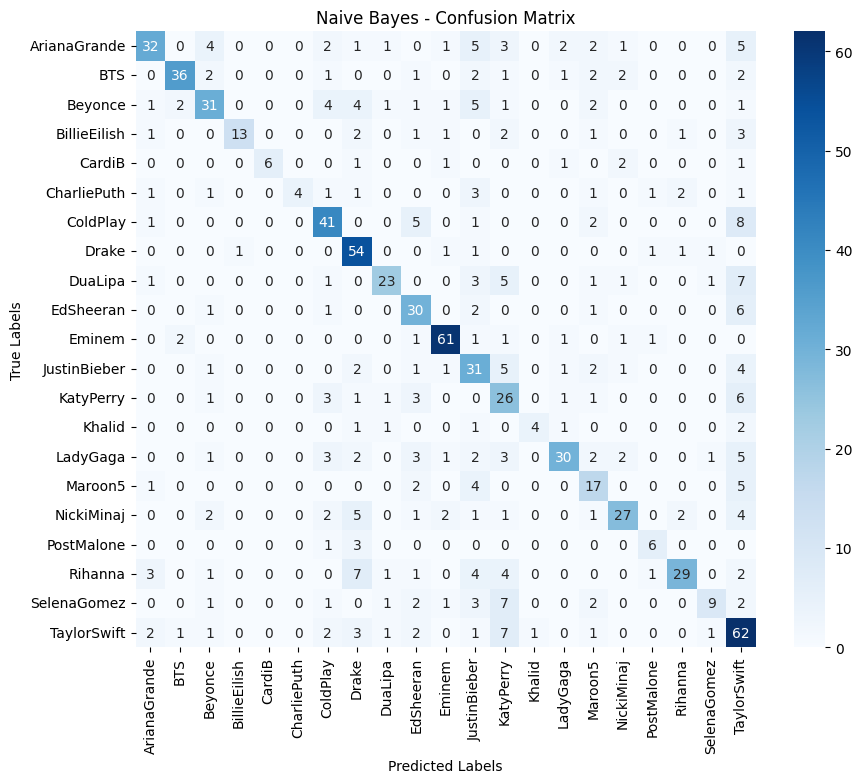

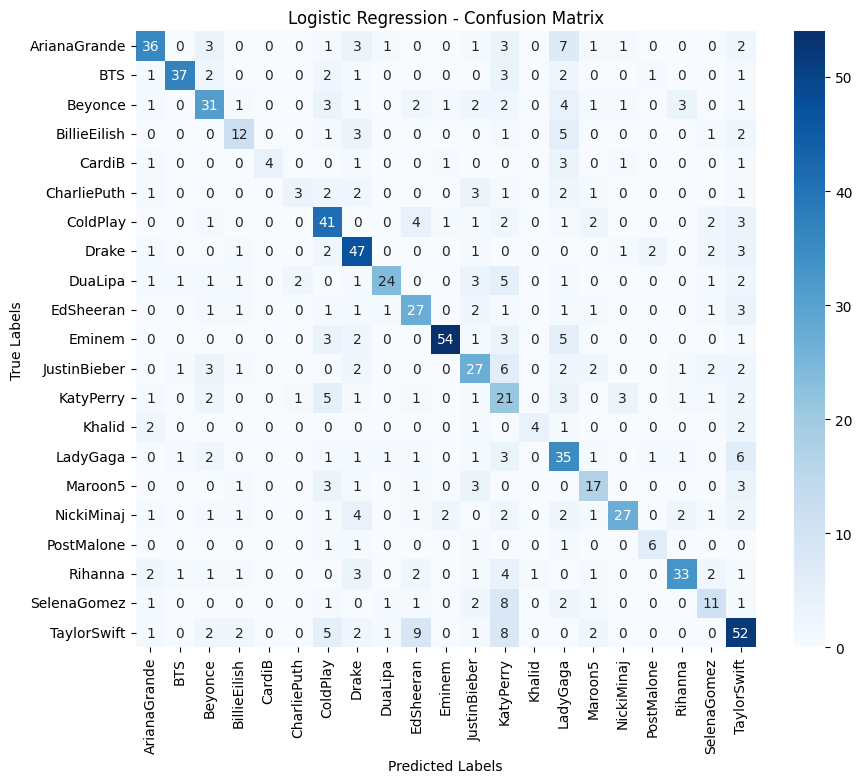

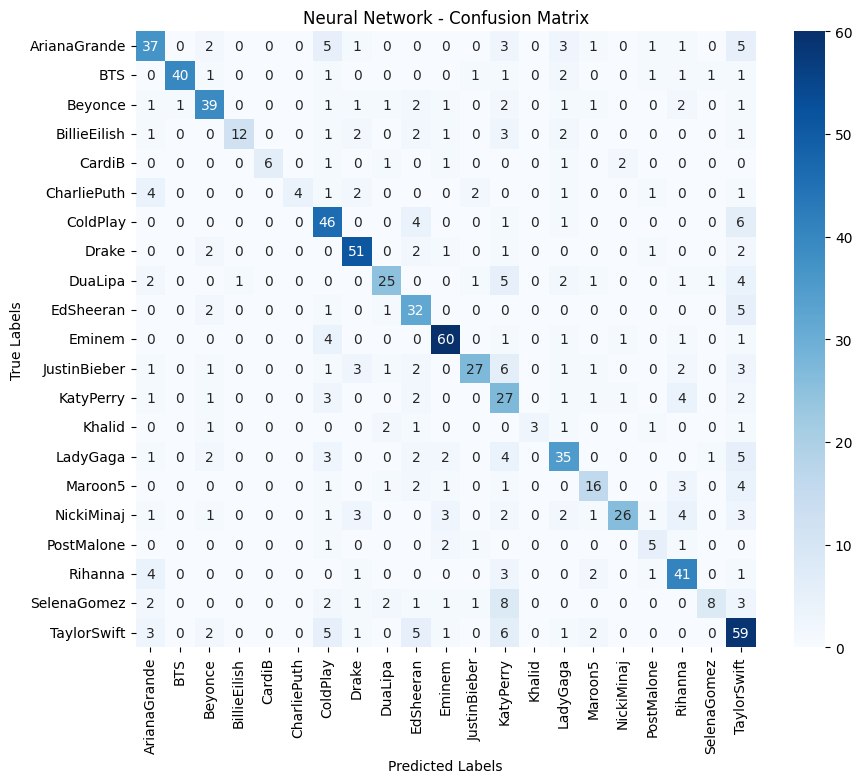

In [9]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter

# Naive Bayes Classifier Implementation (from scratch)
class NaiveBayesClassifier:
    def __init__(self, alpha=0.5, min_word_freq=5):
        self.alpha = alpha
        self.min_word_freq = min_word_freq
        self.word_counts = defaultdict(Counter)
        self.artist_counts = Counter()
        self.vocab = set()

    def train(self, X, y):
        for lyric, artist in zip(X, y):
            self.artist_counts[artist] += 1
            for word in lyric.split():
                self.word_counts[artist][word] += 1
                self.vocab.add(word)
        self.vocab = {word for word in self.vocab if sum(self.word_counts[artist][word] for artist in self.artist_counts) >= self.min_word_freq}
        self.total_words = {artist: sum(self.word_counts[artist][word] for word in self.vocab) for artist in self.artist_counts}
        self.total_docs = len(y)

    def predict(self, lyric):
        artist_probs = {}
        for artist in self.artist_counts:
            log_prob = np.log(self.artist_counts[artist] / self.total_docs)
            for word in lyric.split():
                if word in self.vocab:
                    word_freq = self.word_counts[artist][word]
                    word_prob = (word_freq + self.alpha) / (self.total_words[artist] + self.alpha * len(self.vocab))
                    log_prob += np.log(word_prob)
            artist_probs[artist] = log_prob
        return max(artist_probs, key=artist_probs.get)

# Logistic Regression Model
def train_logistic_regression(X_train, y_train):
    model = LogisticRegression(max_iter=1000, C=0.5)
    model.fit(X_train, y_train)
    return model

# Define Neural Network Model
def build_neural_network(input_dim, num_classes):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        Dropout(0.6),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Model Evaluation Function
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"{model_name} - Accuracy: {accuracy:.2f}, F1 Score: {f1:.2f}")

# Confusion Matrix Visualization
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(title)
    plt.show()

# Train Naive Bayes Classifier
nb_model = NaiveBayesClassifier(alpha=0.5, min_word_freq=5)
nb_model.train(X_train, y_train)
y_dev_pred_nb = [nb_model.predict(text) for text in X_dev]

# Train and Evaluate Logistic Regression
logreg_model = train_logistic_regression(X_combined_train, y_train)
y_dev_pred_logreg = logreg_model.predict(X_combined_dev)

# Train and Evaluate Neural Network
num_classes = len(np.unique(y_train))
nn_model = build_neural_network(X_combined_train.shape[1], num_classes)
y_train_nn = to_categorical([np.unique(y_train).tolist().index(label) for label in y_train], num_classes)
y_dev_nn = to_categorical([np.unique(y_dev).tolist().index(label) for label in y_dev], num_classes)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = nn_model.fit(
    X_combined_train.toarray(), y_train_nn,
    epochs=20, batch_size=64,
    validation_data=(X_combined_dev.toarray(), y_dev_nn),
    callbacks=[early_stopping]
)

# Evaluation on Development Set
y_dev_pred_nn = nn_model.predict(X_combined_dev.toarray()).argmax(axis=1)
y_dev_pred_nn_labels = [np.unique(y_train).tolist()[label] for label in y_dev_pred_nn]

print("\n---- Development Set Results ----")
evaluate_model("Naive Bayes", y_dev, y_dev_pred_nb)
evaluate_model("Logistic Regression", y_dev, y_dev_pred_logreg)
evaluate_model("Neural Network", y_dev, y_dev_pred_nn_labels)

# Test Set Evaluation
print("\n---- Final Test Set Results ----")
y_test_pred_nb = [nb_model.predict(text) for text in X_test]
evaluate_model("Naive Bayes", y_test, y_test_pred_nb)

y_test_pred_logreg = logreg_model.predict(X_combined_test)
evaluate_model("Logistic Regression", y_test, y_test_pred_logreg)

y_test_pred_nn = nn_model.predict(X_combined_test.toarray()).argmax(axis=1)
y_test_pred_nn_labels = [np.unique(y_train).tolist()[label] for label in y_test_pred_nn]
evaluate_model("Neural Network", y_test, y_test_pred_nn_labels)

# Plot Confusion Matrices
plot_confusion_matrix(y_test, y_test_pred_nb, "Naive Bayes - Confusion Matrix")
plot_confusion_matrix(y_test, y_test_pred_logreg, "Logistic Regression - Confusion Matrix")
plot_confusion_matrix(y_test, y_test_pred_nn_labels, "Neural Network - Confusion Matrix")


YOUR REPORT HERE.

**1.	Preprocessing Method**

In this assignment, a series of preprocessing steps were applied to make the lyrics suitable for modeling. First, we converted each song lyric to lower case to prevent case mismatches. Then, punctuation and special characters were removed from the lyrics to ensure that the model only focused on meaningful words. Stopwords were cleaned to prevent the model from considering meaningless words. Finally, each word was reduced to its roots (stemming), thus combining words with different inflections that carry the same meaning into a single representation.

**2.	Selection of the features and reasoning**

Bag-of-Words, TF-IDF, and character n-gram features were employed to differentiate artists based on their lyrics. The Bag-of-Words method, which relies on the raw frequency of words within the lyrics, was utilized to represent the general word preferences of each artist, contributing to a clearer understanding of their word choices by analyzing the repetition frequency of each term. The TF-IDF feature considered whether a given word was used predominantly in a single song or across multiple songs, enabling the identification of unique and distinctive words between artists by emphasizing less common but significant terms in their lyrics. Finally, the character n-gram feature, which examines lyrics at the character level, facilitated the analysis of differences in the artists' writing styles and short expressions. This approach allowed for further distinctions by exploring the artists' specific repeated expressions or concise narrative patterns in greater detail.

**3.	Selection of the classification methods and reasoning**

Naive Bayes, Logistic Regression, and Neural Network models were employed in this homework.
Naive Bayes is an efficient and rapid method commonly used in text classification tasks. This model operates under the assumption of word independence, making it well-suited for classifying song lyrics based on word frequency in relation to the artist. Due to its simplicity and effectiveness in leveraging word frequencies, Naive Bayes was chosen as a suitable baseline model for this task.
Logistic Regression is a model that performs well in classification tasks, especially those with linear discriminants. It was selected for this project due to its ability to work effectively with text-derived features, such as word frequencies and TF-IDF, to achieve accurate classifications.
A Neural Network model was included in the project to enhance the results, add complexity, and gain additional points. Due to the connections between its layers, this model has the capability to learn more intricate data structures. Techniques such as Dropout and early stopping were applied to optimize the Neural Network’s performance, enabling it to capture unique language structures specific to each artist, particularly within high-dimensional datasets.

**4.	Challenges Faced**

The dataset contained numerous instances of the same lyrics being repeated multiple times. Specifically, I observed some lines appearing three or more times, which were subsequently removed to prevent excessive repetition. However, lines repeated twice were still common, which posed a challenge for the model in learning the artists' unique linguistic styles. Additionally, the presence of various symbols in the lyrics—particularly in songs by BTS—introduced further complexity. The inclusion of meaningless characters in these lyrics made it challenging for the model to accurately capture the artist's language style.

**5.	Limitations**

Basic models such as Naive Bayes and Logistic Regression are limited in fully learning the complex structure of the language and the unique style of the artist. Since these models do not take into account the relationships or context between the words in the text, they may have difficulty understanding the unique style of the artist. Therefore, especially in lyrics that contain complex and multi-layered meanings, these simple models may not be able to adequately reflect the language differences of the artists. This leads to a limitation in the classification performance and reveals the need for more advanced models.

**6.	Possible Improvements**

Some improvements can be made to improve the classification performance in this project. First, more complex models, especially LSTM or Transformer-based models, can be used to better learn the context and long-distance relationships in the language. This allows for a more detailed modeling of the artist's language style. In addition, language detection and special preprocessing steps can be added to better handle multilingual content and symbols in the lyrics.







